# 04. Modelo Final e Conclusão

Este é o resultado final do case: a configuração escolhida no notebook 03, a avaliação no conjunto de teste e as principais conclusões.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score
from xgboost import XGBClassifier

from preprocessing import carregar_e_limpar

import warnings
warnings.filterwarnings('ignore')

df = carregar_e_limpar('../data/raw/dataset_ecommerce.csv')

le = LabelEncoder()
y = le.fit_transform(df['categoria'])

idx = np.arange(len(df))
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, random_state=42, stratify=y
)
texto_test = df['texto'].values[idx_test]

## 1. Configuração escolhida

No notebook `03_modelagem_avaliacao.ipynb`, comparamos cinco modelos (Logistic Regression, Random Forest, Extra Trees, HistGradientBoosting e XGBoost) sobre três representações de texto: PCA e UMAP, cada uma em 10, 20 e 30 dimensões, e TF-IDF, em alta dimensão (5000 palavras, sem redução).

A melhor combinação da tabela inteira não envolveu embeddings: foi o TF-IDF com Logistic Regression, sem nenhum ajuste de hiperparâmetros, com F1-macro de 0,947. Otimizar especificamente o XGBoost com Optuna tinha sido uma decisão do projeto, não uma exigência do case, então também rodamos o Optuna na Logistic Regression com TF-IDF, a configuração que já vinha na frente, para comparar os dois candidatos em pé de igualdade.

Depois da otimização, a Logistic Regression com TF-IDF se manteve à frente: F1-macro de 0,949 no teste, contra 0,938 do XGBoost otimizado com UMAP (10D). É essa configuração, TF-IDF + Logistic Regression, que segue para este notebook.

In [2]:
CONFIG_FINAL = {
    'embedding_model': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
    'reducao': 'TF-IDF',
    'dim': 5000,
    'modelo': 'Logistic Regression',
    'hiperparametros': {
        'C': 5.179554356516547,
        'class_weight': 'balanced',
        'max_iter': 2000,
        'random_state': 42,
    },
}
CONFIG_FINAL

{'embedding_model': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
 'reducao': 'TF-IDF',
 'dim': 5000,
 'modelo': 'Logistic Regression',
 'hiperparametros': {'C': 5.179554356516547,
  'class_weight': 'balanced',
  'max_iter': 2000,
  'random_state': 42}}

## 2. Treinar o modelo final

Aqui reaproveitamos a representação já ajustada no treino e salva pelo notebook 02 (neste caso, o TF-IDF), de acordo com a configuração escolhida acima.

In [3]:
if CONFIG_FINAL['reducao'] == 'TF-IDF':
    # TF-IDF é esparso e foi salvo com scipy.sparse.save_npz no notebook 02,
    # em vez de np.savez, por isso o carregamento é diferente do PCA/UMAP.
    X_train_final = sp.load_npz('../data/processed/embeddings_reducoes/tfidf_train.npz')
    X_test_final = sp.load_npz('../data/processed/embeddings_reducoes/tfidf_test.npz')
else:
    dados = np.load(f"../data/processed/embeddings_reducoes/{CONFIG_FINAL['reducao'].lower()}_{CONFIG_FINAL['dim']}.npz")
    X_train_final, X_test_final = dados['X_train'], dados['X_test']

if CONFIG_FINAL['modelo'] == 'XGBoost':
    modelo_final = XGBClassifier(**CONFIG_FINAL['hiperparametros'])
else:
    modelo_final = LogisticRegression(**CONFIG_FINAL['hiperparametros'])

modelo_final.fit(X_train_final, y_train)
print("Modelo final treinado.")

Modelo final treinado.


## 3. Avaliação no teste

In [4]:
y_pred = modelo_final.predict(X_test_final)
y_proba = modelo_final.predict_proba(X_test_final)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

print(f"Accuracy:    {acc * 100:.1f}%")
print(f"F1 Macro:    {f1_macro * 100:.1f}%")
print(f"F1 Weighted: {f1_weighted * 100:.1f}%")
print(f"ROC-AUC:     {roc_auc * 100:.1f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy:    95.0%
F1 Macro:    94.9%
F1 Weighted: 95.0%
ROC-AUC:     99.1%

                      precision    recall  f1-score   support

               Books       0.94      0.93      0.94      1251
Clothing_Accessories       0.97      0.98      0.98      1135
         Electronics       0.93      0.93      0.93      1062
           Household       0.95      0.95      0.95      2113

            accuracy                           0.95      5561
           macro avg       0.95      0.95      0.95      5561
        weighted avg       0.95      0.95      0.95      5561



## 4. Matriz de confusão final

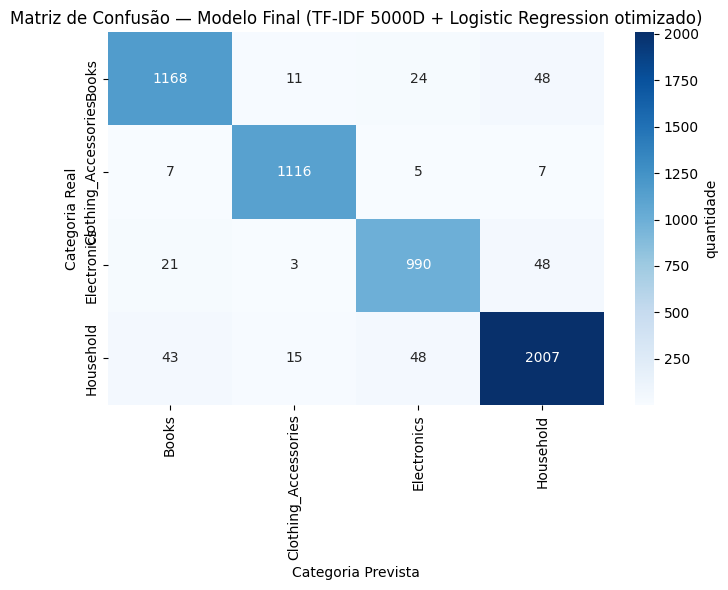

In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'quantidade'})
ax.set_title(f"Matriz de Confusão — Modelo Final ({CONFIG_FINAL['reducao']} {CONFIG_FINAL['dim']}D + {CONFIG_FINAL['modelo']} otimizado)")
ax.set_xlabel('Categoria Prevista')
ax.set_ylabel('Categoria Real')
plt.tight_layout()
plt.show()

## 5. Principais erros

In [6]:
erros = pd.DataFrame({
    'categoria_real': le.inverse_transform(y_test),
    'categoria_prevista': le.inverse_transform(y_pred),
})
apenas_erros = erros[erros['categoria_real'] != erros['categoria_prevista']]

pares = (apenas_erros.groupby(['categoria_real', 'categoria_prevista']).size()
         .reset_index(name='quantidade').sort_values('quantidade', ascending=False))
print(f"Taxa de erro geral: {len(apenas_erros) / len(erros) * 100:.1f}%")
display(pares.head(6))

Taxa de erro geral: 5.0%


,categoria_real,categoria_prevista,quantidade
2,Books,Household,48
11,Household,Electronics,48
8,Electronics,Household,48
9,Household,Books,43
1,Books,Electronics,24
6,Electronics,Books,21


## 6. Exemplos de classificação

In [7]:
probas_max = y_proba.max(axis=1)
resultado_exemplos = pd.DataFrame({
    'texto': [t[:150] for t in texto_test],
    'categoria_real': le.inverse_transform(y_test),
    'categoria_prevista': le.inverse_transform(y_pred),
    'probabilidade (%)': (probas_max * 100).round(1),
})

acertos = resultado_exemplos['categoria_real'] == resultado_exemplos['categoria_prevista']

print("Exemplos corretos com alta confiança:")
display(resultado_exemplos[acertos].sort_values('probabilidade (%)', ascending=False).head(3))

print("\nExemplos em que o modelo errou:")
display(resultado_exemplos[~acertos].sample(min(3, (~acertos).sum()), random_state=1))

Exemplos corretos com alta confiança:


,texto,categoria_real,categoria_prevista,probabilidade (%)
5503,Custom Decor Luxury Handmade Solid Wood Nest o...,Household,Household,100.0
5506,SAIELLIN Mobile Lens 40x60 hd Monocular Telesc...,Electronics,Electronics,100.0
2485,"Ekan Fashionable Fedora Hat for Girls, Boys Fe...",Clothing_Accessories,Clothing_Accessories,100.0



Exemplos em que o modelo errou:


,texto,categoria_real,categoria_prevista,probabilidade (%)
1822,Toreto Magnetic Wireless Music Speaker Twin MA...,Books,Electronics,99.8
5114,The Picture of Dorian Gray About the Author Bo...,Household,Books,90.6
1189,Marvel Encyclopedia Review It's basically geek...,Books,Household,51.2


## 7. Conclusão

**O modelo funciona?** Sim, com boa margem sobre o baseline. O F1-macro da Logistic Regression otimizada ficou em 0,949 e o ROC-AUC em 0,991 no teste, bem acima do baseline de classe majoritária, que tinha F1-macro de apenas 0,138 (ver notebook 03). A taxa de erro geral ficou em 5,0%.

**Esse foi realmente o melhor modelo possível?** Dentro do que foi testado, sim. TF-IDF com Logistic Regression já era a melhor combinação da tabela do notebook 03 mesmo sem ajuste de hiperparâmetros (F1-macro de 0,947), o que levantou a dúvida se fazia sentido continuar otimizando só o XGBoost, decisão que tinha sido do projeto, não uma exigência do case. Por isso também rodamos o Optuna na Logistic Regression com TF-IDF, e comparamos os dois finalistas otimizados em pé de igualdade: a Logistic Regression se manteve à frente, com F1-macro de 0,949 contra 0,938 do XGBoost otimizado com UMAP (10D).

**Qual foi o melhor modelo entre os cinco testados?** Depende muito da representação. Com embeddings (PCA ou UMAP), a Logistic Regression ficou atrás dos quatro modelos de árvore em todas as combinações, e nenhum modelo de árvore dominou sozinho: Extra Trees venceu nas três dimensões do PCA, e em UMAP o vencedor mudou por dimensão (Random Forest em 10D, XGBoost em 20D, HistGradientBoosting em 30D). Com TF-IDF a história se inverte: a Logistic Regression venceu os outros modelos de árvore testados por uma margem grande. Isso sugere que ela funciona bem quando o espaço de features é linear e esparso, como o TF-IDF, mas tem dificuldade quando os embeddings são comprimidos para poucas dimensões por PCA ou UMAP.

**Qual foi a melhor representação?** O TF-IDF, uma representação clássica de contagem de palavras ponderada, teve o melhor resultado geral, superando qualquer combinação de embedding de frase testada, mesmo sem nenhum modelo neural por trás. Entre PCA e UMAP, o UMAP venceu de forma consistente, especialmente com poucas dimensões, mas nenhum dos dois chegou perto do TF-IDF. Uma explicação razoável é que as categorias aqui têm um vocabulário bem característico (por exemplo, "capa" e "página" para `Books`, ou "bateria" e "cabo" para `Electronics`), e é exatamente esse tipo de sinal que o TF-IDF captura bem.

**Qual métrica foi usada para a decisão?** O F1-macro, porque ele dá peso igual a todas as 4 categorias. Isso evita que a categoria mais frequente, `Household`, com cerca de 38% da base, acabe dominando a escolha do modelo, algo que aconteceria se usássemos só a accuracy.

**Quais categorias são mais difíceis?** A categoria `Household` continua concentrando boa parte dos erros, tanto sendo confundida com as outras quanto recebendo previsões que deveriam ser de outras categorias, como mostra a tabela de pares confundidos logo acima. As confusões mais frequentes agora são `Books` e `Electronics` sendo previstas como `Household` (48 vezes cada), e `Household` sendo prevista como `Electronics` (48 vezes) ou como `Books` (43 vezes). Faz sentido que `Household` apareça tanto: é a categoria mais ampla e heterogênea do catálogo, o que aumenta a sobreposição de vocabulário com as demais.

**Quais são as limitações deste trabalho?** A validação cruzada do notebook 03 reaproveita uma única representação ajustada no treino completo, em vez de refazer o ajuste a cada fold, uma simplificação didática para reduzir o custo computacional. O Optuna otimizou hiperparâmetros dos dois finalistas (XGBoost e Logistic Regression), mas não dos outros três modelos testados na comparação inicial, que ficaram só com os hiperparâmetros padrão. O HistGradientBoosting também não entrou na comparação com TF-IDF, porque não aceita entrada esparsa nesta versão do scikit-learn. Também não avaliamos outros modelos de embedding além do `paraphrase-multilingual-MiniLM-L12-v2`, e a deduplicação do notebook 01 remove só repetições exatas de texto e categoria, então descrições quase idênticas, mas não idênticas, ainda podem estar espalhadas entre treino e teste.

**O que eu faria em uma próxima versão?** Testaria outras configurações de TF-IDF, como incluir bigramas ou aumentar o vocabulário além de 5000 palavras, já que essa representação se mostrou a mais forte para o problema. Testaria também densificar o TF-IDF, ou trocar por um modelo que aceite entrada esparsa, para incluir o HistGradientBoosting nessa comparação. Investigaria por que `Household` se confunde tanto com as demais categorias, pode até ser um problema de rótulo, não só do modelo. Rodaria a validação cruzada refazendo a redução de dimensionalidade a cada fold, se o custo computacional permitir, testaria uma deduplicação por similaridade de texto, não só exata, para reduzir ainda mais o risco de vazamento, e testaria estratégias de balanceamento adicionais, como ajuste de threshold, com foco nos pares que mais se confundem.